In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pyrex.core import main, get_fit_params, get_filename
from pyrex.basics import read_pkl
from pyrex.main import glassware
from qcextender.waveform import Waveform
from qcextender import units

/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [2]:
training = get_filename("/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/data")
training_dict = read_pkl(training)

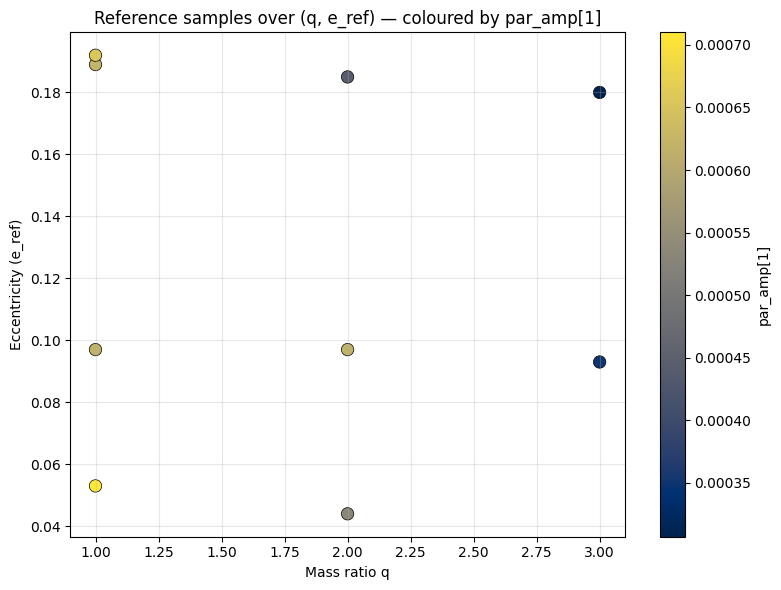

In [3]:
qs = np.array([1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 3.0, 3.0])
e_ref = np.array([0.053, 0.097, 0.189, 0.192, 0.044, 0.097, 0.185, 0.093, 0.18])

x = (20/(2*np.pi))**(2/3)

# compute the value to colour by for each (q, e)
par_vals = []
for q, e in zip(qs, e_ref):
    par_omega, par_amp = get_fit_params(training_dict, q, e, x)
    par_vals.append(par_amp[1])   # or par_amp[0] depending on what you want
par_vals = np.array(par_vals)

# scatter plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(qs, e_ref, c=par_vals, cmap='cividis', s=80, edgecolor='k', linewidth=0.5)
plt.colorbar(sc, label='par_amp[1]')
plt.xlabel("Mass ratio q")
plt.ylabel("Eccentricity (e_ref)")
plt.title("Reference samples over (q, e_ref) — coloured by par_amp[1]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Clearly interpolation in this way is just going wrong for some reason, there is no reason for the above to look like the situation below when interpolated.

In [4]:
eccentricities = np.linspace(1e-30, 0.2, 50)
mass_ratios = np.linspace(1, 3, 50)

x = (20/(2*np.pi))**(2/3)

grid = np.zeros((len(mass_ratios), len(eccentricities)))

for i, e in enumerate(eccentricities):
    for j, q in enumerate(mass_ratios):
        par_omega, par_amp = get_fit_params(training_dict, q, e, (20/(2*np.pi))**(2/3))

        grid[i, j] = par_amp[1]

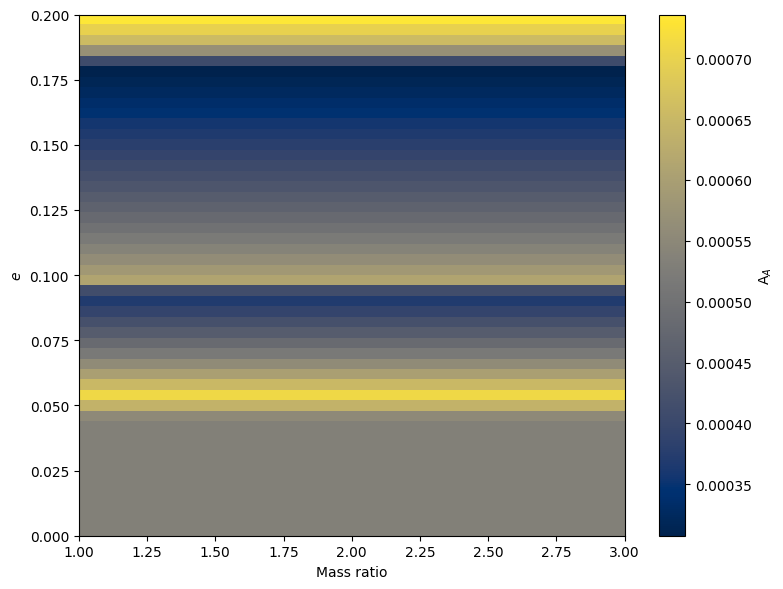

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(grid, origin='lower', aspect='auto',
           extent=[mass_ratios.min(), mass_ratios.max(), 
                   eccentricities.min(), eccentricities.max()],
           cmap='cividis',)
plt.colorbar(label=r"A$_A$")
plt.xlabel(r"Mass ratio")
plt.ylabel(r"$e$")
# plt.title("Mismatch Heatmap: IMRPhenomD Eccentric vs Circular")
plt.tight_layout()
plt.show()